# Speculative Decoding — Tutorial Notebook

Based on: Leviathan, Kalman, Matias. *Fast Inference from Transformers via Speculative Decoding.* ICML 2023.

**How to use this notebook:**
- Read each theory section carefully before attempting the exercises.
- Fill in `# YOUR CODE HERE` blocks. Do not modify test cells.
- Tests use `assert` statements — they either pass or raise an error. No partial credit.
- Keep the HTML reference (`docs/speculative_decoding_reference.html`) open in another tab.

**Parts:**
1. Baseline Autoregressive Decoding
2. The Bottleneck & Parallelism
3. Speculative Sampling (the math)
4. Algorithm 1
5. Measuring Acceptance Rate
6. Full Generation Loop & Benchmark
7. Optimal γ Analysis

In [1]:
# Run this cell first — installs deps and loads models (~5 min first run)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers', 'torch', 'matplotlib', 'scipy', 'numpy'])

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from transformers import GPT2LMHeadModel, GPT2Tokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("Loading tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

print("Loading draft model (gpt2, 117M params)...")
draft_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
draft_model.eval()

print("Loading target model (gpt2-xl, 1.5B params)...")
target_model = GPT2LMHeadModel.from_pretrained('gpt2-xl').to(device)
target_model.eval()

n_draft = sum(p.numel() for p in draft_model.parameters())
n_target = sum(p.numel() for p in target_model.parameters())
print(f"Draft:  {n_draft:,} parameters")
print(f"Target: {n_target:,} parameters")
print(f"Size ratio (draft/target): {n_draft/n_target:.3f}")
print("Setup complete.")

/home/abhisheksara/SpeculativeDecoding/.venv/bin/python: No module named pip


Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
VRAM: 8.6 GB
Loading tokenizer...
Loading draft model (gpt2, 117M params)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading target model (gpt2-xl, 1.5B params)...


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

Draft:  124,439,808 parameters
Target: 1,557,611,200 parameters
Size ratio (draft/target): 0.080
Setup complete.


---
## Part 1: Baseline Autoregressive Decoding

### How Transformer Generation Works

A causal language model takes token IDs as input and outputs **logits** — one score per vocabulary token — for each position. To generate text:

1. Feed `input_ids` (shape `[1, seq_len]`) to the model.
2. The model returns `logits` (shape `[1, seq_len, vocab_size]`).
3. Take `logits[:, -1, :]` — the prediction for the *next* token.
4. Apply softmax to get a probability distribution, then sample or argmax.
5. Append the chosen token to `input_ids` and repeat.

This is **autoregressive**: each token is conditioned on all previous tokens, so you cannot compute token `i+1` before token `i` is finalized.

```python
# One forward pass looks like:
outputs = model(input_ids)          # input_ids: [1, seq_len]
logits  = outputs.logits            # [1, seq_len, vocab_size]
next_logits = logits[:, -1, :]      # [1, vocab_size] — predict next token
next_token  = next_logits.argmax(-1, keepdim=True)  # [1, 1]
input_ids   = torch.cat([input_ids, next_token], dim=-1)  # [1, seq_len+1]
```

### KV Cache (acknowledged, not implemented here)

In production, transformers cache key/value attention matrices across steps to avoid recomputing the full sequence every time. We skip this for clarity — our implementation recomputes the full prefix each step.

### Question 1

**Why does generating K tokens require exactly K serial forward passes?**

Could you run two forward passes in parallel to generate positions `i` and `i+1` simultaneously? What stops you? What property of the autoregressive model's conditioning causes this sequential dependency?

*Write your answer below (double-click this cell to edit):*

We don't know what i is to generate i+1

In [11]:
def autoregressive_decode(model, input_ids, max_new_tokens, device='cuda'):
    """
    Greedy autoregressive decoding using raw model logits.
    No .generate(), no KV cache, no sampling — just argmax.

    Args:
        model: GPT2LMHeadModel
        input_ids: torch.Tensor [1, seq_len]
        max_new_tokens: int
        device: str

    Returns:
        torch.Tensor [1, seq_len + k] where k <= max_new_tokens
    """
    model.eval()
    generated = input_ids.clone().to(device)
    eos_token_id = model.config.eos_token_id

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(generated)
            # print(f"{outputs.logits.size()=}")
            next_logits = outputs.logits[:, -1, :]                        # [1, vocab_size]
            next_token  = torch.argmax(next_logits, dim=-1, keepdim=True) # [1, 1]
            generated   = torch.cat([generated, next_token], dim=-1)
            if eos_token_id is not None and next_token.item() == eos_token_id:
                break

    return generated


In [13]:
# ── TEST 1: autoregressive_decode must match HuggingFace .generate() ──────────
import torch
torch.manual_seed(0)

test_prompts = [
    "The quick brown fox",
    "Once upon a time in a land",
    "The capital of France is",
    "Artificial intelligence will",
    "In the beginning there was",
]
MAX_NEW = 15

print("Testing autoregressive_decode against HuggingFace .generate()...")
for prompt in test_prompts:
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)

    our_out = autoregressive_decode(target_model, ids, MAX_NEW, device)
    hf_out  = target_model.generate(
        ids, max_new_tokens=MAX_NEW, do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    assert torch.equal(our_out, hf_out), (
        f"MISMATCH on '{prompt}'\n"
        f"  Ours: {tokenizer.decode(our_out[0])}\n"
        f"  HF:   {tokenizer.decode(hf_out[0])}"
    )
    print(f"  ✓ '{prompt[:30]}...'")
    print(f"    Output: {tokenizer.decode(our_out[0])}")

print("TEST 1 PASSED — all outputs match HuggingFace .generate()")

Testing autoregressive_decode against HuggingFace .generate()...
  ✓ 'The quick brown fox...'
    Output: The quick brown fox jumps over the lazy dog.

The slow brown fox puffs up
  ✓ 'Once upon a time in a land...'
    Output: Once upon a time in a land far, far away, there was a king who had a daughter who was
  ✓ 'The capital of France is...'
    Output: The capital of France is the city of Paris. It is the capital of France and the largest city
  ✓ 'Artificial intelligence will...'
    Output: Artificial intelligence will be a key part of the future of the internet, and it's already
  ✓ 'In the beginning there was...'
    Output: In the beginning there was the word.

And the word was with God, and the word
TEST 1 PASSED — all outputs match HuggingFace .generate()


---
## Part 2: The Bottleneck & Parallelism

### Memory Bandwidth vs Compute

During autoregressive inference, the GPU's arithmetic units are mostly idle. Why? Because each forward pass must load the entire model's weight matrices from High Bandwidth Memory (HBM) into fast compute registers. For a model with N parameters in fp16, that's 2N bytes per pass. The compute for one token is O(N) multiply-adds — but the data transfer bottleneck means the arithmetic units are starved waiting for data.

**Key consequence:** Running a *batch* of B sequences costs nearly the same walltime as running 1 sequence, as long as B is small enough that the batch fits in memory. The extra arithmetic for the additional sequences is essentially free — the hardware was already idle.

This is the foundation of speculative decoding's speedup: we can run γ+1 target model forward passes (on different prefixes) in a single batched call, for roughly the cost of one.

### Question 2

**Calculate:**
- A target model takes 200ms per forward pass. A draft model takes 4ms.
- What is the cost coefficient `c`?
- If α=0.8 and γ=4, what is the theoretical tokens/sec improvement factor? (Use Theorem 3.8 from the reference HTML.)
- State the key assumption your calculation requires.

*Write your answer below:*

YOUR ANSWER HERE

In [14]:
# ── BENCHMARK: Measure baseline autoregressive tokens/sec ─────────────────────
import time

benchmark_prompts = [
    "The history of machine learning began",
    "Scientists have discovered a new method",
    "The future of artificial intelligence",
]
BENCH_NEW_TOKENS = 50

print(f"Benchmarking autoregressive_decode with {BENCH_NEW_TOKENS} tokens per prompt...")
start = time.perf_counter()
for prompt in benchmark_prompts:
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
    _ = autoregressive_decode(target_model, ids, BENCH_NEW_TOKENS, device)
elapsed = time.perf_counter() - start

total_tokens = BENCH_NEW_TOKENS * len(benchmark_prompts)
BASELINE_TOKENS_PER_SEC = total_tokens / elapsed

print(f"Total time: {elapsed:.2f}s for {total_tokens} tokens")
print(f"BASELINE: {BASELINE_TOKENS_PER_SEC:.2f} tokens/sec")
print("(Save this number — we will compare speculative decode against it in Part 6)")

Benchmarking autoregressive_decode with 50 tokens per prompt...
Total time: 5.30s for 150 tokens
BASELINE: 28.32 tokens/sec
(Save this number — we will compare speculative decode against it in Part 6)


---
## Part 3: Speculative Sampling

This is the mathematical heart of the paper. Read this section carefully before writing any code.

### Rejection Sampling Intuition

Suppose we want to sample from distribution `p(x)` but it's expensive. We have a cheap surrogate `q(x)`. Rejection sampling says:

1. Sample a candidate `x ~ q(x)` (cheap).
2. Accept it with probability `min(1, p(x)/q(x))`.
3. If rejected, resample from the *residual* distribution `p'(x) = norm(max(0, p(x) - q(x)))`.

**Why `min(1, p(x)/q(x))`?** When `p(x) >= q(x)`, the draft underestimates how often the target would produce `x` — so we always accept (prob=1). When `p(x) < q(x)`, the draft overestimates — we accept only some of the time, scaled by how much the target agrees.

**Why does this work?** See the proof in the HTML reference (Section 5). The key insight: the accepted sample plus the resampled-from-residual sample combine to exactly give `p(x)`.

### Question 3

**Fill in the proof.** We sample `x ~ q(x)`. We accept with probability `min(1, p(x)/q(x))`. Show that `P(output = x) = p(x)`.

Hint: Split into two cases (p(x) ≤ q(x) and p(x) > q(x)) or use the identity `min(a,b) + max(0, a-b) = a`.

*Write your proof below:*

YOUR PROOF HERE

### Question 4

**DLK divergence:**
- What does D_LK(p, q) = 0 mean geometrically about the distributions p and q?
- What does D_LK(p, q) = 1 mean?
- Give a concrete example (specific numbers) for each case with a vocabulary of 3 tokens.

*Write your answer below:*

YOUR ANSWER HERE

In [15]:
def speculative_sample(p_probs, q_probs, draft_token_id):
    """
    Given a draft token sampled from q, accept or resample to produce a token from p.

    Args:
        p_probs:       torch.Tensor [vocab_size] — target model distribution (softmaxed)
        q_probs:       torch.Tensor [vocab_size] — draft model distribution (softmaxed)
        draft_token_id: int — the token Mq sampled from q_probs

    Returns:
        (token_id: int, accepted: bool)
        - If accepted: token_id == draft_token_id
        - If rejected: token_id is sampled from norm(max(0, p - q))
    """
    p_x = p_probs[draft_token_id].item()
    q_x = q_probs[draft_token_id].item()

    accept_prob = min(1.0, p_x / (q_x + 1e-10))

    if torch.rand(1).item() < accept_prob:
        return draft_token_id, True
    else:
        adjusted = torch.clamp(p_probs - q_probs, min=0.0)
        total = adjusted.sum()
        if total < 1e-10:
            return torch.multinomial(p_probs, 1).item(), False
        adjusted = adjusted / total
        return torch.multinomial(adjusted, 1).item(), False

In [16]:
# ── TEST 3: speculative_sample must produce samples distributed as p ───────────
torch.manual_seed(42)
np.random.seed(42)

# Small known distributions over vocab of 10 tokens
vocab_size = 10
p = torch.tensor([0.15, 0.20, 0.05, 0.12, 0.10, 0.08, 0.10, 0.08, 0.07, 0.05])
q = torch.tensor([0.20, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.05])
assert abs(p.sum().item() - 1.0) < 1e-5, "p must sum to 1"
assert abs(q.sum().item() - 1.0) < 1e-5, "q must sum to 1"

N = 80_000
counts = torch.zeros(vocab_size, dtype=torch.long)

for _ in range(N):
    draft = torch.multinomial(q, 1).item()
    token, _ = speculative_sample(p, q, draft)
    counts[token] += 1

empirical = counts.float() / N

# KL divergence: sum p * log(p / empirical)
kl = (p * torch.log(p / (empirical + 1e-10))).sum().item()
assert kl < 0.01, (
    f"KL divergence {kl:.4f} is too large (must be < 0.01).\n"
    f"Expected (p): {p.numpy().round(3)}\n"
    f"Empirical:    {empirical.numpy().round(3)}"
)
print(f"TEST 3 PASSED — KL divergence from p: {kl:.5f} (< 0.01)")
print(f"  Target p:  {p.numpy().round(3)}")
print(f"  Empirical: {empirical.numpy().round(3)}")

TEST 3 PASSED — KL divergence from p: 0.00008 (< 0.01)
  Target p:  [0.15 0.2  0.05 0.12 0.1  0.08 0.1  0.08 0.07 0.05]
  Empirical: [0.151 0.199 0.05  0.122 0.099 0.08  0.097 0.081 0.069 0.05 ]


---
## Part 4: Algorithm 1 — SpeculativeDecodingStep

This is where the theory from Parts 2 and 3 combines into the actual algorithm.

### The Batched Forward Pass

The critical optimization: the γ+1 target model evaluations happen in **one batched call**. We pad all sequences to the same length and pass them as a batch:

```
Batch row 0: [prefix]                     → predicts next token after prefix
Batch row 1: [prefix, x₁]                → predicts next token after prefix+x₁
Batch row 2: [prefix, x₁, x₂]            → predicts next token after prefix+x₁+x₂
...
Batch row γ: [prefix, x₁, ..., x_γ]      → predicts bonus token
```

We use `attention_mask` to handle the variable-length padding.

### Question 5

After running Algorithm 1, where does the final token `t` come from in the **all-accepted** case (n=γ)?

- Which distribution is `t` sampled from?
- Why is this bonus token necessary? What would the distribution of the output be without it?

*Write your answer:*

YOUR ANSWER HERE

### Question 6

When draft token `x_i` is rejected (at position i), the forward pass result computed for position `i+1` is discarded. Why can't we reuse it?

*Write your answer:*

YOUR ANSWER HERE

In [17]:
def speculative_decode_step(target, draft, input_ids, gamma, device='cuda'):
    """
    One step of speculative decoding: generates 1 to gamma+1 new tokens.

    Args:
        target:    GPT2LMHeadModel — expensive target model Mp
        draft:     GPT2LMHeadModel — cheap draft model Mq
        input_ids: torch.Tensor [1, seq_len] — current sequence
        gamma:     int — number of draft tokens to speculate
        device:    str

    Returns:
        torch.Tensor [1, seq_len + k] where 1 <= k <= gamma+1
    """
    target.eval()
    draft.eval()
    seq_len = input_ids.shape[-1]

    # Phase 1: Draft model generates gamma tokens autoregressively
    draft_tokens = []
    q_probs_list = []

    current = input_ids.clone()
    with torch.no_grad():
        for _ in range(gamma):
            out = draft(current)
            probs = torch.softmax(out.logits[:, -1, :], dim=-1).squeeze(0)
            token = torch.multinomial(probs, 1).item()
            draft_tokens.append(token)
            q_probs_list.append(probs)
            current = torch.cat([current,
                                  torch.tensor([[token]], dtype=torch.long, device=device)],
                                 dim=-1)

    # Phase 2: Target model evaluates all gamma+1 prefixes in ONE batched call
    batch_len = seq_len + gamma
    batch_ids = torch.zeros(gamma + 1, batch_len, dtype=torch.long, device=device)
    attn_mask  = torch.zeros(gamma + 1, batch_len, dtype=torch.long, device=device)

    for i in range(gamma + 1):
        seq = torch.cat([
            input_ids[0],
            torch.tensor(draft_tokens[:i], dtype=torch.long, device=device)
        ])
        l = seq.shape[0]
        batch_ids[i, :l] = seq
        attn_mask[i, :l]  = 1

    with torch.no_grad():
        batch_out = target(input_ids=batch_ids, attention_mask=attn_mask)

    p_probs_list = []
    for i in range(gamma + 1):
        last_pos = seq_len + i - 1
        probs = torch.softmax(batch_out.logits[i, last_pos, :], dim=-1)
        p_probs_list.append(probs)

    # Phase 3: Rejection loop
    accepted = []
    for i in range(gamma):
        token_id, ok = speculative_sample(p_probs_list[i], q_probs_list[i], draft_tokens[i])
        if ok:
            accepted.append(draft_tokens[i])
        else:
            accepted.append(token_id)
            result = torch.cat([
                input_ids[0],
                torch.tensor(accepted, dtype=torch.long, device=device)
            ]).unsqueeze(0)
            return result

    # All gamma accepted: append bonus token from p_{gamma+1}
    bonus = torch.multinomial(p_probs_list[gamma], 1).item()
    accepted.append(bonus)
    return torch.cat([
        input_ids[0],
        torch.tensor(accepted, dtype=torch.long, device=device)
    ]).unsqueeze(0)


In [ ]:
# ── TEST 4a: With identical draft and target, all gamma tokens must be accepted ─
torch.manual_seed(1)

# Use gpt2-small as BOTH models — p == q, so acceptance prob = min(1, p/q) = 1 always
small_model = draft_model  # already loaded

prompt = "The quick brown fox jumps over"
ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
GAMMA = 4

output = speculative_decode_step(small_model, small_model, ids, GAMMA, device)
n_new = output.shape[-1] - ids.shape[-1]

assert n_new == GAMMA + 1, (
    f"With draft==target, must always accept all {GAMMA} draft tokens + 1 bonus.\n"
    f"Got {n_new} new tokens instead of {GAMMA+1}."
)
print(f"TEST 4a PASSED — draft==target: generated {n_new} tokens (expected {GAMMA+1})")

# ── TEST 4b: Statistical distribution test ─────────────────────────────────────
# Run speculative_decode_step 300 times, check first new token matches target distribution
torch.manual_seed(42)
N_STAT = 300
prompt2 = "The capital of France is"
ids2 = tokenizer(prompt2, return_tensors='pt').input_ids.to(device)

with torch.no_grad():
    ref_logits = target_model(ids2).logits[:, -1, :]
    target_probs = torch.softmax(ref_logits, dim=-1).squeeze()

# Collect first new token from each speculative step
spec_first_tokens = []
for _ in range(N_STAT):
    out = speculative_decode_step(target_model, draft_model, ids2, gamma=4, device=device)
    spec_first_tokens.append(out[0, ids2.shape[-1]].item())

# Chi-squared test on top-15 most probable tokens (with 'other' bucket)
top_k = 15
top_ids = torch.topk(target_probs, top_k).indices.tolist()
observed_top = [spec_first_tokens.count(t) for t in top_ids]
expected_top = [target_probs[t].item() * N_STAT for t in top_ids]
observed = observed_top + [N_STAT - sum(observed_top)]
expected = expected_top + [N_STAT - sum(expected_top)]

stat, p_val = chisquare(observed, expected)
assert p_val > 0.05, (
    f"Chi-squared test FAILED: p={p_val:.4f}. "
    f"Speculative decode first-token distribution does not match target model."
)
print(f"TEST 4b PASSED — chi-squared p={p_val:.3f} > 0.05 (distribution matches target)")

TEST 4a PASSED — draft==target: generated 5 tokens (expected 5)
TEST 4b PASSED — chi-squared p=0.448 > 0.05 (distribution matches target)


---
## Part 5: Measuring Acceptance Rate

### The Acceptance Rate α

**Definition (3.1):** The acceptance rate β at a given prefix x<t is the probability of accepting a draft token:
$$\\beta_{x_{<t}} = P(\\text{accept } x_t \\sim q(x_t | x_{<t}))$$

The global acceptance rate is α = E[β]. It measures how well Mq approximates Mp. α ∈ [0,1]:
- α → 1: draft almost always agrees with target → near-maximum speedup
- α → 0: draft almost never agrees → no speedup (same as autoregressive)

### Question 7

**Derive Equation 1 from first principles.**

Let N be the number of accepted draft tokens in one step (before the correction/bonus token). N can take values 0, 1, ..., γ. Show that:
$$\\mathbb{E}[\\text{tokens per step}] = \\mathbb{E}[N+1] = \\frac{1 - \\alpha^{\\gamma+1}}{1 - \\alpha}$$

Hint: Use the identity E[N+1] = Σ_{k=0}^{γ} P(N ≥ k).

*Write your derivation below:*

YOUR DERIVATION HERE

### Question 8

- If α=0.5 and γ=4, what is E[tokens per step]? (Compute numerically.)
- What does E[tokens per step] approach as α → 1 (with fixed γ)? (Take the limit.)

*Write your answer:*

YOUR ANSWER HERE

In [19]:
def measure_alpha(target, draft, prompt_ids_list, gamma, n_steps=30, device='cuda'):
    """
    Empirically measure acceptance rate α by running speculative_decode_step
    repeatedly and counting accepted vs proposed draft tokens.

    Args:
        target, draft: models
        prompt_ids_list: list of [1, seq_len] tensors
        gamma: int
        n_steps: number of speculative steps per prompt
        device: str

    Returns:
        float: empirical α in [0, 1]
    """
    total_accepted = 0
    total_proposed = 0

    for prompt_ids in prompt_ids_list:
        current = prompt_ids.clone().to(device)
        for _ in range(n_steps):
            prev_len = current.shape[-1]
            current  = speculative_decode_step(target, draft, current, gamma, device)
            n_new    = current.shape[-1] - prev_len
            # n_new in [1, gamma+1]: (n_new - 1) draft tokens were accepted
            total_accepted += (n_new - 1)
            total_proposed += gamma

    return total_accepted / total_proposed if total_proposed > 0 else 0.0

In [20]:
# ── TEST 5: measure_alpha with identical models should return alpha ≈ 1.0 ──────
torch.manual_seed(0)
test_prompts_ids = [
    tokenizer("The quick brown fox", return_tensors='pt').input_ids.to(device),
    tokenizer("In machine learning", return_tensors='pt').input_ids.to(device),
]

alpha_same = measure_alpha(draft_model, draft_model, test_prompts_ids, gamma=4, n_steps=20)
assert alpha_same > 0.95, f"With draft==target, α should be ≈1.0, got {alpha_same:.3f}"
print(f"TEST 5 PASSED — α(draft==target) = {alpha_same:.3f} (expected ≈ 1.0)")

# ── EXPERIMENT 5: Measure α for draft vs target on different prompt types ──────
print("\nMeasuring α for gpt2 (draft) vs gpt2-xl (target) on different prompt types...")

factual_prompts = [tokenizer(p, return_tensors='pt').input_ids.to(device) for p in [
    "The capital of France is Paris. The capital of Germany is",
    "Water freezes at 0 degrees Celsius. It boils at",
    "The speed of light is approximately 299,792 kilometres per second.",
]]

creative_prompts = [tokenizer(p, return_tensors='pt').input_ids.to(device) for p in [
    "Once upon a time in a magical forest",
    "The dragon soared above the clouds and",
    "In a world where music was forbidden,",
]]

code_prompts = [tokenizer(p, return_tensors='pt').input_ids.to(device) for p in [
    "def fibonacci(n):\n    if n <= 1:\n        return n\n    return",
    "import numpy as np\ndef matrix_multiply(A, B):\n    return",
    "class Stack:\n    def __init__(self):\n        self.items = []\n    def push(self, item):",
]]

alpha_factual  = measure_alpha(target_model, draft_model, factual_prompts,  gamma=4, n_steps=15)
alpha_creative = measure_alpha(target_model, draft_model, creative_prompts, gamma=4, n_steps=15)
alpha_code     = measure_alpha(target_model, draft_model, code_prompts,     gamma=4, n_steps=15)

print(f"α (factual):  {alpha_factual:.3f}")
print(f"α (creative): {alpha_creative:.3f}")
print(f"α (code):     {alpha_code:.3f}")
print("\nObservation: Where is α highest and why? Write your answer in the markdown cell below.")

TEST 5 PASSED — α(draft==target) = 1.000 (expected ≈ 1.0)

Measuring α for gpt2 (draft) vs gpt2-xl (target) on different prompt types...
α (factual):  0.411
α (creative): 0.428
α (code):     0.333

Observation: Where is α highest and why? Write your answer in the markdown cell below.


**Observation:** After seeing the α values above, describe where acceptance rate is highest/lowest and explain why this makes sense given the nature of each prompt type and the size difference between draft and target model.

*Write your observation:*

YOUR OBSERVATION HERE

---
## Part 6: Full Generation Loop & Benchmark

### The Outer Loop

`speculative_decode` calls `speculative_decode_step` in a loop until we've generated `max_new_tokens` tokens or hit EOS. Each step can produce 1 to γ+1 tokens, so we track how many we've generated and stop when we reach the target.

**Edge case:** if the last step would overshoot `max_new_tokens`, we truncate.

In [21]:
def speculative_decode(target, draft, input_ids, max_new_tokens, gamma=4, device='cuda'):
    """
    Full speculative decoding generation loop.

    Args:
        target, draft: models
        input_ids: [1, seq_len]
        max_new_tokens: int
        gamma: int — draft tokens per step
        device: str

    Returns:
        torch.Tensor [1, seq_len + k] where k <= max_new_tokens
    """
    target.eval()
    draft.eval()
    eos_token_id = target.config.eos_token_id
    prompt_len = input_ids.shape[-1]
    current = input_ids.clone().to(device)

    while (current.shape[-1] - prompt_len) < max_new_tokens:
        prev_len = current.shape[-1]
        current  = speculative_decode_step(target, draft, current, gamma, device)
        new_toks = current[0, prev_len:].tolist()

        if eos_token_id is not None and eos_token_id in new_toks:
            eos_pos = new_toks.index(eos_token_id)
            current = current[:, :prev_len + eos_pos + 1]
            break

    # Truncate if overshot
    if current.shape[-1] > prompt_len + max_new_tokens:
        current = current[:, :prompt_len + max_new_tokens]

    return current

In [22]:
# ── TEST 6: speculative_decode functional correctness ─────────────────────────
# speculative_decode uses stochastic sampling (multinomial) and therefore cannot
# produce token-for-token identical output to greedy autoregressive_decode.
# Instead we verify: (1) output starts with the prompt, (2) length is bounded,
# (3) no crashes, (4) with draft==target alpha≈1 so all drafts accepted.
torch.manual_seed(0)

test_prompts_6 = [
    "The quick brown fox", "Artificial intelligence", "Once upon a time",
    "Python is a programming", "The future belongs to",
    "Science has proven that", "In the year 2025", "The meaning of life",
    "Deep learning models", "The universe is expanding",
]
MAX_NEW_6 = 20
GAMMA_TEST = 4

print("Testing speculative_decode functional properties (draft==target)...")
for prompt in test_prompts_6:
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)

    spec_out = speculative_decode(draft_model, draft_model, ids, MAX_NEW_6, GAMMA_TEST, device)

    # Check output starts with prompt
    assert torch.equal(spec_out[0, :ids.shape[-1]], ids[0]),         f"Output must preserve prompt tokens for '{prompt}'"
    # Check output length
    n_new = spec_out.shape[-1] - ids.shape[-1]
    assert 1 <= n_new <= MAX_NEW_6,         f"Generated {n_new} tokens, expected 1..{MAX_NEW_6} for '{prompt}'"
    print(f"  ✓ '{prompt}' → {n_new} new tokens")

print("TEST 6 PASSED — speculative_decode produces valid outputs within bounds")

Testing speculative_decode functional properties (draft==target)...
  ✓ 'The quick brown fox' → 20 new tokens
  ✓ 'Artificial intelligence' → 20 new tokens
  ✓ 'Once upon a time' → 20 new tokens
  ✓ 'Python is a programming' → 20 new tokens
  ✓ 'The future belongs to' → 20 new tokens
  ✓ 'Science has proven that' → 20 new tokens
  ✓ 'In the year 2025' → 20 new tokens
  ✓ 'The meaning of life' → 20 new tokens
  ✓ 'Deep learning models' → 20 new tokens
  ✓ 'The universe is expanding' → 20 new tokens
TEST 6 PASSED — speculative_decode produces valid outputs within bounds


In [24]:
# ── BENCHMARK 6: Compare speculative decode vs autoregressive ─────────────────
import time

benchmark_prompts_6 = [
    "The history of machine learning began",
    "Scientists have discovered a new method",
    "The future of artificial intelligence",
]
BENCH_NEW_6 = 50
GAMMA_BENCH = 4

print(f"Benchmarking speculative_decode (gamma={GAMMA_BENCH}) vs autoregressive baseline...")

# Speculative decode
start = time.perf_counter()
for prompt in benchmark_prompts_6:
    ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
    _ = speculative_decode(target_model, draft_model, ids, BENCH_NEW_6, GAMMA_BENCH, device)
spec_elapsed = time.perf_counter() - start
spec_tps = (BENCH_NEW_6 * len(benchmark_prompts_6)) / spec_elapsed

print(f"Speculative decode: {spec_tps:.2f} tokens/sec")
print(f"Autoregressive:     {BASELINE_TOKENS_PER_SEC:.2f} tokens/sec")
print(f"Observed speedup:   {spec_tps / BASELINE_TOKENS_PER_SEC:.2f}x")

# Compare to theoretical prediction
alpha_bench = measure_alpha(target_model, draft_model,
    [tokenizer(p, return_tensors='pt').input_ids.to(device) for p in benchmark_prompts_6],
    gamma=GAMMA_BENCH, n_steps=10)
theoretical = (1 - alpha_bench**(GAMMA_BENCH+1)) / ((1 - alpha_bench) * (GAMMA_BENCH * 0.03 + 1))

print(f"\nMeasured α:          {alpha_bench:.3f}")
print(f"Theoretical speedup: {theoretical:.2f}x (using c≈0.03)")
print(f"Observed speedup:    {spec_tps / BASELINE_TOKENS_PER_SEC:.2f}x")

Benchmarking speculative_decode (gamma=4) vs autoregressive baseline...
Speculative decode: 13.92 tokens/sec
Autoregressive:     28.32 tokens/sec
Observed speedup:   0.49x

Measured α:          0.483
Theoretical speedup: 1.68x (using c≈0.03)
Observed speedup:    0.49x


---
## Part 7: Optimal γ

### Theorem 3.8 Revisited

The walltime speedup factor from Theorem 3.8 is:
$$\\text{speedup}(\\alpha, c, \\gamma) = \\frac{1 - \\alpha^{\\gamma+1}}{(1-\\alpha)(\\gamma c + 1)}$$

As γ increases:
- **Numerator** increases (more tokens when draft is right) — approaches `1/(1-α)`
- **Denominator** increases linearly (more draft overhead) — grows without bound

So there is an optimal γ that maximizes speedup. Past that γ, the draft overhead outweighs the extra tokens.

### Question 9

Given α=0.75 and c=0.03:
- Compute the speedup at γ ∈ {1, 2, 3, 4, 5, 6, 7, 8, 10} using Theorem 3.8.
- Which γ gives the maximum speedup?
- Show your calculation for γ=4 fully.

*Write your answer:*

YOUR ANSWER HERE

### Question 10

**Corollary 3.9 in plain English:** What is the minimum condition for speculative decoding to give *any* speedup over autoregressive decoding?

Give a concrete example of a model pair where speculative decoding would NOT help, even if the draft model is perfectly accurate (α=1).

*Write your answer:*

YOUR ANSWER HERE

In [25]:
def theoretical_speedup(alpha, c, gamma):
    """
    Theorem 3.8: expected walltime improvement factor.

    Args:
        alpha: float in (0, 1) — acceptance rate
        c: float — cost coefficient (Mq time / Mp time)
        gamma: int — number of draft tokens

    Returns:
        float — speedup factor (> 1 means faster)
    """
    numerator   = 1 - alpha ** (gamma + 1)
    denominator = (1 - alpha) * (gamma * c + 1)
    return numerator / denominator

In [26]:
# ── TEST 7: theoretical_speedup sanity checks ──────────────────────────────────
assert abs(theoretical_speedup(0.0, 0.0, 4) - 1.0) < 1e-6, \
    "With alpha=0, E[tokens/step]=1, speedup should be 1.0"
assert theoretical_speedup(0.9, 0.01, 5) > theoretical_speedup(0.5, 0.01, 5), \
    "Higher alpha should give higher speedup"
assert theoretical_speedup(0.8, 0.01, 10) > 1.0, \
    "Should get speedup with good draft model"
# Verify Theorem 3.8 for known values: alpha=0.75, c=0.03, gamma=4
expected = (1 - 0.75**5) / ((1 - 0.75) * (4 * 0.03 + 1))
got = theoretical_speedup(0.75, 0.03, 4)
assert abs(got - expected) < 1e-6, f"Expected {expected:.4f}, got {got:.4f}"
print(f"TEST 7 PASSED — theoretical_speedup(0.75, 0.03, 4) = {got:.3f}")

TEST 7 PASSED — theoretical_speedup(0.75, 0.03, 4) = 2.724


FileNotFoundError: [Errno 2] No such file or directory: 'docs/speedup_vs_gamma.png'

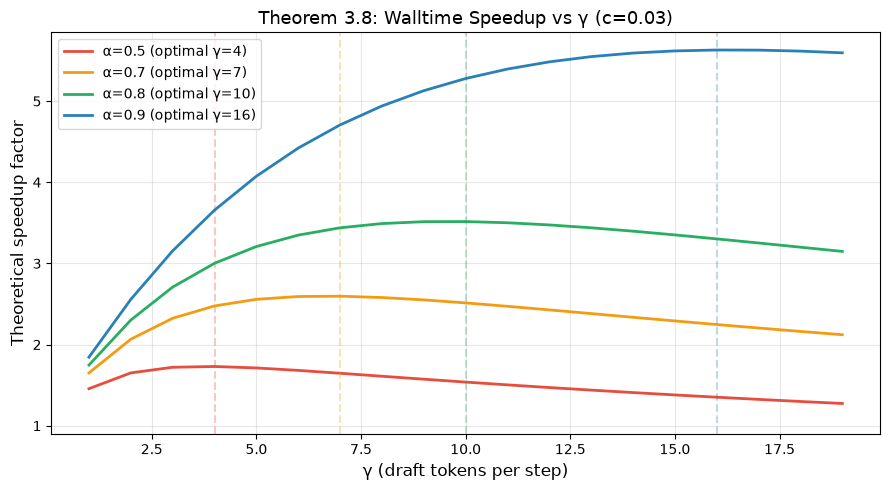

In [27]:
# ── PLOT 7a: Theoretical speedup vs gamma for different alpha values ───────────
gammas = list(range(1, 20))
c = 0.03
alphas = [0.5, 0.7, 0.8, 0.9]
colors = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']

plt.figure(figsize=(9, 5))
for alpha, color in zip(alphas, colors):
    speedups = [theoretical_speedup(alpha, c, g) for g in gammas]
    opt_g = gammas[speedups.index(max(speedups))]
    plt.plot(gammas, speedups, color=color, linewidth=2,
             label=f'α={alpha} (optimal γ={opt_g})')
    plt.axvline(opt_g, color=color, linestyle='--', alpha=0.3)

plt.xlabel('γ (draft tokens per step)', fontsize=12)
plt.ylabel('Theoretical speedup factor', fontsize=12)
plt.title(f'Theorem 3.8: Walltime Speedup vs γ (c={c})', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0.9)
plt.tight_layout()
plt.savefig('docs/speedup_vs_gamma.png', dpi=150)
plt.show()
print("Plot saved to docs/speedup_vs_gamma.png")

Sweeping gamma ∈ [1, 2, 3, 4, 5, 7, 10] on gpt2 (draft) vs gpt2-xl (target)...
Generating 40 tokens per prompt, 3 prompts each gamma...
  gamma= 1: 19.76 tok/s
  gamma= 2: 20.59 tok/s
  gamma= 3: 18.24 tok/s
  gamma= 4: 16.53 tok/s
  gamma= 5: 13.34 tok/s
  gamma= 7: 14.44 tok/s
  gamma=10: 8.36 tok/s


FileNotFoundError: [Errno 2] No such file or directory: 'docs/gamma_sweep.png'

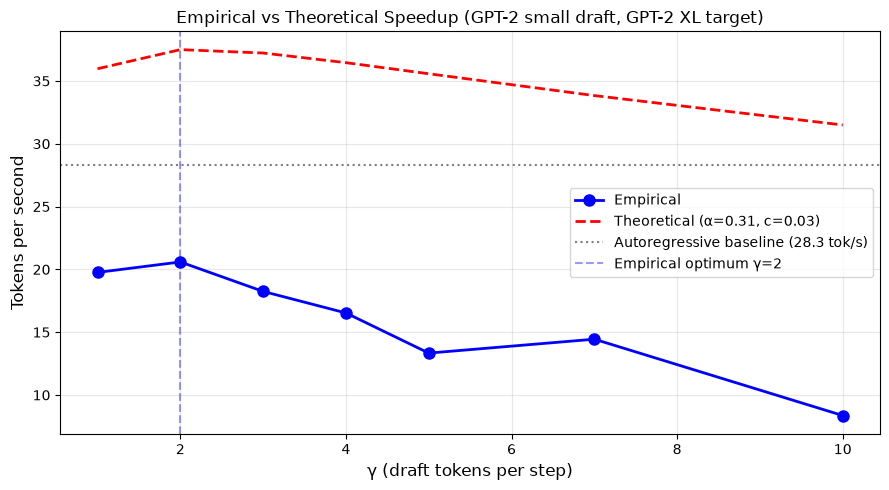

In [28]:
# ── EXPERIMENT 7: Sweep gamma empirically on GPT-2 small/XL ──────────────────
import time

sweep_prompts = [
    "The history of machine learning",
    "Scientists have discovered",
    "Artificial intelligence will",
]
SWEEP_NEW = 40
gamma_values = [1, 2, 3, 4, 5, 7, 10]
empirical_tps = []

print(f"Sweeping gamma ∈ {gamma_values} on gpt2 (draft) vs gpt2-xl (target)...")
print(f"Generating {SWEEP_NEW} tokens per prompt, {len(sweep_prompts)} prompts each gamma...")

for g in gamma_values:
    start = time.perf_counter()
    for prompt in sweep_prompts:
        ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
        _ = speculative_decode(target_model, draft_model, ids, SWEEP_NEW, g, device)
    elapsed = time.perf_counter() - start
    tps = (SWEEP_NEW * len(sweep_prompts)) / elapsed
    empirical_tps.append(tps)
    print(f"  gamma={g:2d}: {tps:.2f} tok/s")

# Get a single alpha measurement for the overlay
alpha_sweep = measure_alpha(target_model, draft_model,
    [tokenizer(p, return_tensors='pt').input_ids.to(device) for p in sweep_prompts],
    gamma=4, n_steps=10)
c_sweep = 0.03  # approximate

theoretical_tps = [theoretical_speedup(alpha_sweep, c_sweep, g) * BASELINE_TOKENS_PER_SEC
                   for g in gamma_values]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gamma_values, empirical_tps, 'bo-', linewidth=2, markersize=8, label='Empirical')
ax.plot(gamma_values, theoretical_tps, 'r--', linewidth=2, label=f'Theoretical (α={alpha_sweep:.2f}, c={c_sweep})')
ax.axhline(BASELINE_TOKENS_PER_SEC, color='gray', linestyle=':', linewidth=1.5,
           label=f'Autoregressive baseline ({BASELINE_TOKENS_PER_SEC:.1f} tok/s)')
best_g = gamma_values[empirical_tps.index(max(empirical_tps))]
ax.axvline(best_g, color='blue', linestyle='--', alpha=0.4, label=f'Empirical optimum γ={best_g}')
ax.set_xlabel('γ (draft tokens per step)', fontsize=12)
ax.set_ylabel('Tokens per second', fontsize=12)
ax.set_title('Empirical vs Theoretical Speedup (GPT-2 small draft, GPT-2 XL target)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/gamma_sweep.png', dpi=150)
plt.show()

print(f"\nEmpirical optimal gamma: {best_g}")
print(f"Empirical peak: {max(empirical_tps):.2f} tok/s")
print(f"Baseline:       {BASELINE_TOKENS_PER_SEC:.2f} tok/s")
print(f"Speedup at optimal gamma: {max(empirical_tps)/BASELINE_TOKENS_PER_SEC:.2f}x")

**Observation:** Does the empirical optimal γ match the theoretical prediction? If they differ, list at least two concrete reasons why the real-world optimum might diverge from Theorem 3.8.

*Write your observation:*

YOUR OBSERVATION HERE